In [13]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

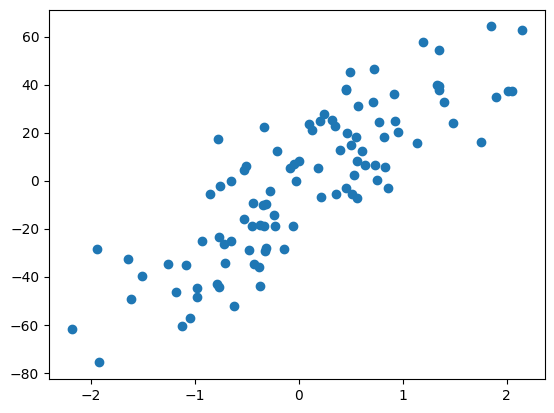

In [14]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)
plt.scatter(X, y)

In [15]:
from sklearn.model_selection import cross_val_score

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
(lr.coef_, lr.intercept_)

(array([27.82809103]), np.float64(-2.29474455867698))

In [20]:
print(f"cross_val_score : {np.mean(cross_val_score(lr, X, y, scoring='r2', cv=10))}")

cross_val_score : 0.6375011587464419


In [28]:
class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m  = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.lr*loss_slope_b)

            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            self.m = self.m - (self.lr*loss_slope_m)

        print(f"b:{self.b}, m:{self.m}")

    def predict(self, X):
        return self.m*X + self.b
        



In [29]:
gd = GDRegressor(0.001, 55)

In [30]:
gd.fit(X, y)

b:-2.296349932049713, m:27.831326521155287


In [31]:
gd.predict(X)

array([[-22.12312706],
       [-14.46269341],
       [-14.92488061],
       [ 24.22218992],
       [  4.32354923],
       [ 21.67230503],
       [ -9.0684423 ],
       [  2.8509412 ],
       [-22.36272727],
       [-14.26095599],
       [ 53.78991886],
       [  8.75940313],
       [  3.4870012 ],
       [ -8.76507027],
       [-23.68825952],
       [ 10.3156554 ],
       [ 15.51246986],
       [  7.70991078],
       [-47.24694702],
       [ 46.38736949],
       [-24.25496111],
       [-16.54501764],
       [-28.13315072],
       [ 57.55166058],
       [ -8.06716709],
       [-47.91449386],
       [-11.72054513],
       [-11.26147861],
       [-15.69355498],
       [-16.85670402],
       [ 17.79689532],
       [ 19.01997057],
       [ 10.32462897],
       [-37.40851694],
       [-63.16666924],
       [-35.28812787],
       [  3.7556182 ],
       [ 34.72813475],
       [-32.55405577],
       [ 13.3521392 ],
       [-44.40083631],
       [ -2.36283968],
       [-10.03720248],
       [ 10

In [32]:
print(f"cross_val_score : {np.mean(cross_val_score(gd, X, y, scoring='r2', cv=10))}")

TypeError: Cannot clone object '<__main__.GDRegressor object at 0x12ae867c0>' (type <class '__main__.GDRegressor'>): it does not seem to be a scikit-learn estimator as it does not implement a 'get_params' method.